# **DAA Mini Project**

### Academic Year 2025/26

Work by:

  * Gonçalo Sobral, No. 129850 ##

  * Rafael Silva, No. 129834 ##


## **Introduction**

## Base Classes

The `Vertex`, `Edge`, and `Graph` classes were adapted from the Week 7 exercises and serve as the foundation for the entire `CentralityAnalyser` implementation.
### `Vertex` Class
Represents a vertex of a graph. The `_vertex_id` attribute is the identifier of a single vertex (in our project, the character's name).

The comparison methods (`__eq__`, `__lt__`, `__le__`, etc.) allow `Vertex` objects to be used as dictionary keys and in sorting operations.

**Spatial complexity:** $O(1)$ per vertex - only stores `_vertex_id`.

---

### `Edge` Class
Represents an undirected edge between two vertices, with an associated weight (in our case, the number of co-occurrences between two characters). Some of the methods used in `CentralityAnalyser` are:

- `endpoints()` - returns the pair `(vertex_1, vertex_2)`: $O(1)$.
- `opposite(vertex)` - given one endpoint, returns the other: $O(1)$ (comparison of `Vertex` objects). Used extensively in BFS: `edge.opposite(current_obj)`.
- `cost()` - returns the edge weight: $O(1)$. Used in `load_graph_csv` and when removing Eddard-Stark in section 3.2.

**Spatial complexity:** $O(1)$ per edge - stores two pointers to `Vertex` and an integer.

---

### `Graph` Class
Implements an **undirected graph** using an **adjacency list with nested dictionaries**. The structure consists of two dictionaries:

- `_vertices`: maps `vertex_id` (string) -> `Vertex` object. Allows finding a vertex by its name in $O(1)$ -> used in `get_vertex(vertex_id)`, `has_vertex(vertex_id)`.
- `_adjancencies`: maps a `Vertex` object -> a `{Vertex -> Edge}` dictionary. For each vertex, the inner dictionary stores all incident edges indexed by the opposite vertex. This allows:
  - `incident_edges(vertex_id)`: iterating incident edges in $O(\deg(v))$ - iterates `self._adjancencies[vertex].values()`.
  - `degree(vertex_id)`: $O(1)$ - `len(self._adjancencies[vertex])`.
  - `has_edge(u, v)`: $O(1)$ - checks whether `vertex_v in self._adjancencies[vertex_u]`.

**`insert_edge(u_id, v_id, weight=0)`:** inserts the vertices if they don't yet exist (`insert_vertex`), then creates an `Edge` object and inserts it into both inner dictionaries (once in `_adjancencies[vertex_u]` and once in `_adjancencies[vertex_v]`), to ensure the edge is undirected. Increments `_m` only if the edge did not already exist. Complexity: $O(1)$.

**`edges()`:** uses a generator with a `seen` dictionary to avoid returning each edge twice (since it is stored on both endpoint vertices). Total complexity: $O(n + m)$.

**`remove_vertex(vertex_id)`:** removes all incident edges before removing the vertex, updating `_adjancencies` and `_m`. Complexity: $O(\deg(v))$.

**Total spatial complexity: $O(n + m)$** - `_vertices` has $n$ entries; the sum of all entries in the inner dictionaries of `_adjancencies` is $2m$ (since each edge appears twice).


In [3]:
class Vertex:
    '''Estrutura de Vértice para um grafo'''
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id

    def __hash__(self):
        return hash(self._vertex_id)

    def __str__(self):
        return 'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id

    def __lt__(self, vertex):
        return self._vertex_id < vertex._vertex_id

    def __le__(self, vertex):
        return self._vertex_id <= vertex._vertex_id

    def __gt__(self, vertex):
        return self._vertex_id > vertex._vertex_id

    def __ge__(self, vertex):
        return self._vertex_id >= vertex._vertex_id

    def vertex_id(self):
        return self._vertex_id


class Edge:
    '''Estrutura de Aresta para um Grafo: (origem, destino) e peso'''
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash((self._vertex_1, self._vertex_2))

    def __str__(self):
        return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def __eq__(self, other):
        return self._vertex_1 == other._vertex_1 and self._vertex_2 == other._vertex_2

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight

    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None


class Graph:
    '''Representação de um grafo não orientado usando dicionários encadeados'''
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0

    def __str__(self):
        if self._n == 0:
            return "DAA-Graph: <empty>\n"
        ret = "DAA-Graph:\n"
        for vertex in self._adjancencies.keys():
            ret += str(vertex) + ": "
            for edge in self.incident_edges(vertex.vertex_id()):
                ret += str(edge) + "; "
            ret += "\n"
        return ret

    def is_directed(self):
        return False

    def order(self):
        return self._n

    def size(self):
        return self._m

    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices

    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return vertex_v in self._adjancencies[vertex_u]

    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)
        if not self.has_edge(u_id, v_id):
            self._m += 1
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e

    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])

    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id]

    def get_edge(self, u_id, v_id):
        if not self.has_edge(u_id, v_id):
            return None
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return self._adjancencies[vertex_u][vertex_v]

    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {}
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():
            yield edge

    def has_neighbors(self, vertex_id):
        if not self.has_vertex(vertex_id):
            return False
        return self.degree(vertex_id) == 0

    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:
                del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

In [4]:
import csv
import os

def load_graph_csv(filepath):
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"File {filepath} not found.")
    
    graph = Graph()
    with open(filepath, mode='r', newline='', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        for row in reader:
            source = row['Source'].strip()
            target = row['Target'].strip()
            weight = int(row['Weight'])
            graph.insert_edge(source, target, weight)

    return graph
    


We created a function that reads a CSV file with `Source`, `Target`, `Weight` columns and builds a `Graph` object, to make it easier to construct the graph.

- `os.path.isfile(filepath)`: checks whether the file exists before trying to open it, to avoid errors.
- `csv.DictReader`: reads each row as a dictionary `{column -> value}`, which allows access by column name instead of an index.
- `.strip()`: removes spaces and invisible characters from character names, avoiding possible duplicates - we could have skipped this, but decided to keep it since we had no guarantee that the CSV files were 100% correct and error-free.
- `int(row['Weight'])`: converts the weight from a string to an integer. The weight represents the number of co-occurrences between two characters, but **is not used in the distance calculations** of `CentralityAnalyser` (BFS treats all edges as weight 1, as indicated in the support document).
- `graph.insert_edge(source, target, weight)`: each call is $O(1)$. If the vertices don't yet exist, `insert_edge` automatically creates them via `insert_vertex`.

**Time complexity:** $O(m)$ - reads $m$ lines from the CSV, each with an $O(1)$ `insert_edge`.

**Spatial complexity:** $O(n + m)$ - the `Graph` has $n$ vertices and $m$ edges in the adjacency structure.


## 1. CentralityAnalyzer API

In [5]:
from collections import deque
import matplotlib.pyplot as plt
class CentralityAnalyser:
    def __init__(self, graph):
        self._graph = graph
        self._vertex_ids = [v.vertex_id() for v in graph.vertices()]
        self._n = graph.order()
        self._m = graph.size()
    #2.1
    def bfs(self, source):
        if not self._graph.has_vertex(source):
            raise ValueError(f"Source vertex {source} not found in graph.")
        
        
        distances = {source: 0}

        queue = deque([source])
        while queue:
            current_id = queue.popleft()
            current_obj=self._graph.get_vertex(current_id)
            for edge in self._graph.incident_edges(current_id):
                neighbor_obj = edge.opposite(current_obj)
                neighbor_id = neighbor_obj.vertex_id()

                if neighbor_id not in distances:
                    distances[neighbor_id] = distances[current_id] + 1
                    queue.append(neighbor_id)

        return distances
    #2.2
    def num_components(self):
        count=0
        visited = set()

        for vertex in self._graph.vertices():
            if vertex.vertex_id() not in visited:
                count += 1
                reachable = self.bfs(vertex.vertex_id())
                visited.update(reachable.keys())
        
        return count

    def largest_component(self):
        visited = set()
        largest_size = 0
        largest_component_vertices = []

        for vertex in self._graph.vertices():
            if vertex.vertex_id() not in visited:
                reachable = self.bfs(vertex.vertex_id())
                visited.update(reachable.keys())
                component_size = len(reachable)

                if component_size > largest_size:
                    largest_size = component_size
                    largest_component_vertices = list(reachable.keys())

        largest_component_set = set(largest_component_vertices)
        subgraph = Graph()
        for v_id in largest_component_vertices:
            for edge in self._graph.incident_edges(v_id):
                u, v = edge.endpoints()
                u_id, v_id2 = u.vertex_id(), v.vertex_id()
                if u_id in largest_component_set and v_id2 in largest_component_set:
                    subgraph.insert_edge(u_id, v_id2, edge.cost())

        return subgraph

    #2.3
    def degree_distribution(self):
        degree_count = {}
        for vertex in self._graph.vertices():
            degree = self._graph.degree(vertex.vertex_id())
            degree_count[degree] = degree_count.get(degree, 0) + 1
        return degree_count

    #2.4
    def diameter(self):
        largest_comp = self.largest_component()
        largest_comp_ids = [v.vertex_id() for v in largest_comp.vertices()]
        max_diameter = 0
        best_pair = (None, None)

        for source_id in largest_comp_ids:
            distances = self.bfs(source_id)
            if distances:
                farthest = max(distances, key=distances.get)
                current_max = distances[farthest]
                if current_max > max_diameter:
                    max_diameter = current_max
                    best_pair = (source_id, farthest)

        return max_diameter, best_pair

    #3.1
    def degree_centrality(self):
        centrality = {}

        if self._n <= 1:
            for vertex in self._vertex_ids:
                centrality[vertex] = 0.0
            return centrality
        
        denominator = self._n - 1
        for vertex in self._vertex_ids:
            centrality[vertex] = self._graph.degree(vertex) / denominator
        return centrality

    #3.2
    def closeness_centrality(self):
        centrality = {}
        if self._n <= 1:
            for vid in self._vertex_ids:
                centrality[vid] = 0.0
            return centrality

        n_minus_1 = self._n - 1

        for vid in self._vertex_ids:
            distances = self.bfs(vid)
            rv = len(distances) - 1
            sum_distances = sum(distances.values())
            if rv == 0 or sum_distances == 0:
                centrality[vid] = 0.0
            else:
                centrality[vid] = (rv ** 2) / (n_minus_1 * sum_distances)
        return centrality

    #3.3
    def eigenvector_centrality(self):
        centrality = {}
        valid_nodes = set(v.vertex_id() for v in self.largest_component().vertices())
        epsilon=1e-6
        max_iter=100

        for vid in self._vertex_ids:
            centrality[vid] = 1.0 if vid in valid_nodes else 0.0

        k_iterations = 0

        for _ in range(max_iter):
            new_scores = {}
            max_diff = 0.0

            for node in valid_nodes:
                score_sum = 0.0
                for edge in self._graph.incident_edges(node):
                    neighbour = edge.opposite(self._graph.get_vertex(node)).vertex_id()
                    score_sum += centrality[neighbour]
                new_scores[node] = score_sum

            max_score = max(new_scores.values()) if new_scores else 1.0
            if max_score == 0:
                max_score = 1.0
            for node in valid_nodes:
                new_scores[node] /= max_score

            for node in valid_nodes:
                diff = abs(new_scores[node] - centrality[node])
                if diff > max_diff:
                    max_diff = diff

            for node in valid_nodes:
                centrality[node] = new_scores[node]

            k_iterations += 1

            if max_diff < epsilon:
                break

        return centrality, k_iterations
    
    
    #3.4
    def betweenness_centrality(self):
        all_vertices = [v.vertex_id() for v in self._graph.vertices()]
        n = len(all_vertices)

        BC = {vid: 0.0 for vid in all_vertices}

        for s in all_vertices:
            S     = []
            P     = {} 
            sigma = {} 
            d     = {} 
            for vid in all_vertices:
                P[vid]     = []
                sigma[vid] = 0.0
                d[vid]     = -1

            sigma[s] = 1.0
            d[s]     = 0
            Q = [s]
            head = 0

            while head < len(Q):
                v = Q[head]; head += 1
                S.append(v)
                v_obj = self._graph.get_vertex(v)
                for edge in self._graph.incident_edges(v):
                    w_obj = edge.opposite(v_obj)
                    w = w_obj.vertex_id()

                    if w not in d:
                        continue

                    if d[w] < 0:
                        Q.append(w)
                        d[w] = d[v] + 1

                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]
                        P[w].append(v)

            delta = {vid: 0.0 for vid in all_vertices}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
                if w != s:
                    BC[w] += delta[w]
        norm = 1.0 / ((n - 1) * (n - 2)) if n > 2 else 1.0
        for vid in BC:
            BC[vid] *= norm
        return BC


## 1.2 Constructor and Data Structure

The class we created takes a `Graph` object and stores references to its attributes. The internal data structure is an adjacency list, implemented as a dictionary as follows: `{vertex_id → Vertex}` where each `Vertex` maintains a dictionary of incident edges.

- `self._graph = graph` - store reference: $O(1)$.
- `[v.vertex_id() for v in graph.vertices()]` - iterates over the $n$ vertices of the internal `_vertices` dictionary, calling `vertex_id()` in $O(1)$ each: cost $O(n)$.
- `graph.order()` and `graph.size()` - return internal counters: $O(1)$ each.

**Time complexity of the constructor:** iterating over `graph.vertices()` costs $O(n)$; the remaining operations are $O(1)$. Total: $O(n)$.

**Memory space estimate:**
1- Vertex dictionary: $O(n)$.
2- For each vertex, a dictionary of incident edges: in total, each undirected edge is stored twice (once per endpoint) -> $O(m)$ overall.
3- The attributes `_vertex_ids`, `_n`, `_m` are $O(n)$, $O(1)$, $O(1)$, respectively.

**Concrete numbers:**
- got_book1: $n=187$, $m=684$ -> $187 + 2 \times 684 = 1\ 555$ dictionary entries
- got_full: $n=796$, $m=2823$ -> $796 + 2 \times 2823 = 6\ 442$ entries
- marvel_full: $n=6421$, $m=167112$ -> $6421 + 2 \times 167112 = 340\ 645$ entries

**Total space: $O(n + m)$**, which is good for representing sparse graphs.


## 2. Structural Analysis of the Graphs
### 2.1 BFS
The BFS algorithm traverses a graph layer by layer, ensuring that all vertices at distance d are visited before vertices at distance d+1.

**(1)** Initialize `distances` with the source vertex at distance 0: $O(1)$.  
**(2)** Create the queue with the initial vertex: $O(1)$.  
**(3–4)** The `while queue` runs as long as there are vertices in the queue. Each vertex is inserted at most once and removed exactly once with `popleft()` - $O(1)$. Total removals: $\leq n$ -> contributes $O(n)$.  
**(5)** `get_vertex` is a lookup in the `_vertices` dictionary - $O(1)$.  
**(6)** `incident_edges(current_id)` iterates over the vertex's `_incident` dictionary. Summing over all processed vertices, each edge is examined twice -> $2m$, giving a total contribution of $O(m)$.  
**(7)** checking whether `neighbor_id` is in `distances` - $O(1)$.
**(8)** `queue.append` - $O(1)$. Total insertions: $\leq n$.

**Auxiliary structure:** We use a `deque` (from the collections library). Each vertex is inserted at most once (when discovered) and removed once (when all its neighbors have been visited), cost $O(1)$, as mentioned above. Each visited vertex is added to the queue with distance d+1.

**Time complexity: $O(n) + O(2m) = O(n + m)$**

**Spatial complexity: $O(n)$** - `distances` and `queue` each have at most $n$ entries.

**Concrete numbers** for got_book1 ($n=187$, $m=684$): each `bfs` call performs at most $187 + 2 \times 684 = 1\ 555$ elementary operations.

### 2.2 Connectivity
`num_components()` applies BFS to still-unvisited vertices, to count the number of components.  
`largest_component()` reuses the same logic to identify the vertices of the largest component, but instead of returning just that list, it iterates over the incident edges of those vertices to build and return the corresponding subgraph (`Graph`).


In [6]:
graph_b1   = load_graph_csv("got_book1.csv")
graph_full = load_graph_csv("got_full.csv")
ca_b1      = CentralityAnalyser(graph_b1)
ca_full    = CentralityAnalyser(graph_full)

for name, g, ca in [("got_book1", graph_b1, ca_b1),
                     ("got_full",  graph_full, ca_full)]:
    n_comp = ca.num_components()
    lc     = ca.largest_component()
    lc_ids = [v.vertex_id() for v in lc.vertices()]
    print(f"=== {name} ===")
    print(f"  Vértices: {g.order()}   Arestas: {g.size()}")
    print(f"  Número de componentes conexas: {n_comp}")
    print(f"  Tamanho da maior componente: {lc.order()}")
    fora = g.order() - lc.order()
    print(f"  Vértices fora da maior componente: {fora}")
    lc_set = set(lc_ids)
    fora_ids = [v.vertex_id() for v in g.vertices() if v.vertex_id() not in lc_set]
    if fora_ids:
        print(f"  Personagens fora: {fora_ids}")
    print()

p1, p2 = "Tyrion-Lannister", "Daenerys-Targaryen"
distances_p1 = ca_b1.bfs(p1)
if p2 in distances_p1:
    print(f"got_book1 — {p1} e {p2} estão conectados (distância {distances_p1[p2]}).")
    prev  = {p1: None}
    queue = deque([p1])
    while queue:
        curr = queue.popleft()
        curr_obj = graph_b1.get_vertex(curr)
        for edge in graph_b1.incident_edges(curr):
            nb = edge.opposite(curr_obj).vertex_id()
            if nb not in prev:
                prev[nb] = curr
                queue.append(nb)
    path, node = [], p2
    while node is not None:
        path.append(node); node = prev[node]
    path.reverse()
    print(f"  Caminho: {' -> '.join(path)}")
else:
    print(f"got_book1 — {p1} e {p2} NÃO estão conectados.")

=== got_book1 ===
  Vértices: 187   Arestas: 684
  Número de componentes conexas: 1
  Tamanho da maior componente: 187
  Vértices fora da maior componente: 0

=== got_full ===
  Vértices: 796   Arestas: 2823
  Número de componentes conexas: 1
  Tamanho da maior componente: 796
  Vértices fora da maior componente: 0

got_book1 — Tyrion-Lannister e Daenerys-Targaryen estão conectados (distância 2).
  Caminho: Tyrion-Lannister -> Eddard-Stark -> Daenerys-Targaryen


**(1)** Create an empty `visited` set: $O(1)$.  
**(2)** Iterate over all $n$ vertices: $O(n)$ iterations in total.  
**(3)** Check membership in the `visited` set: $O(1)$.  
**(4)** `bfs()` is called when the vertex has not yet been visited - i.e., once per connected component. Since each component is traversed exactly once, the total cost of all `bfs` calls combined is $O(n + m)$.  
**(5)** `visited.update(reachable.keys())` - $O(1))$. Summed over all components: $O(n)$.

**Time complexity of `num_components`: $O(n + m)$**

`largest_component()` reuses the same per-component BFS logic to identify the vertices of the largest component, but instead of returning just that list, it does a second pass, iterating over the incident edges of those vertices to build the corresponding subgraph (`Graph`) and return it - this extra pass has a cost proportional to $O(n'+m')$ (vertices/edges of the component), still dominated by $O(n+m)$.

**Time complexity of `largest_component`: $O(n + m)$**

**Spatial complexity of `num_components`: $O(n)$** - `visited` has at most $n$ entries.

**Spatial complexity of `largest_component`: $O(n + m)$** - besides `visited` ($O(n)$), the constructed subgraph (`subgraph`) stores up to $n$ vertices and $m$ edges of the largest component, unlike the previous version which only stored the list of `vertex_id`s (cost $O(n)$).

Concrete numbers:
- got_book1 ($n=187$, $m=684$, 1 component): 1 call to `bfs` -> $\leq 1\ 555$ operations.
- got_full ($n=796$, $m=2823$, 1 component): 1 call to `bfs` -> $\leq 6\ 442$ operations.


**got_book1:** The graph is **connected** - it has only 1 connected component with all 187 vertices. This means any character from book 1 is linked to any other through some chain of co-occurrences.

**got_full:** The graph is also **connected** - 1 connected component with all 796 vertices. Across the 5 books, the network does not fragment; on the contrary, new characters are introduced already linked to the main network.

**Tyrion Lannister and Daenerys Targaryen are connected in got_book1.** Through the path: Tyrion-Lannister -> Eddard-Stark -> Daenerys-Targaryen.

**got_book1 vs got_full comparison:** The network becomes progressively more connected throughout the saga. The number of vertices almost quadruples (187 -> 796) but the network stays connected, indicating that new characters introduced in later books are always integrated into the main network through already-existing characters.


### 2.3 Degree Distribution and Top-10
`degree_distribution()` iterates over all vertices, obtains the degree in $O(1)$ (size of the adjacency dictionary) and updates the counter.

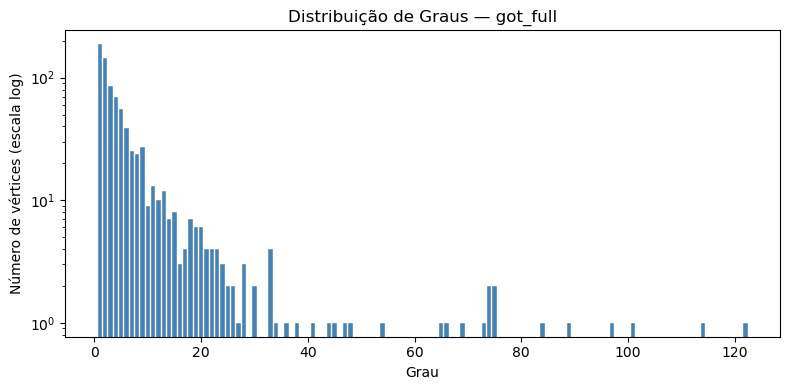

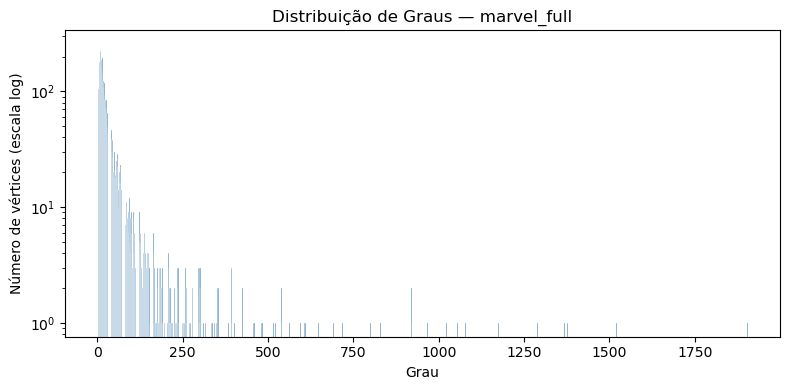

Top-10 por grau — got_book1:
   1. Eddard-Stark                   grau=66
   2. Robert-Baratheon               grau=50
   3. Tyrion-Lannister               grau=46
   4. Catelyn-Stark                  grau=43
   5. Jon-Snow                       grau=37
   6. Robb-Stark                     grau=35
   7. Sansa-Stark                    grau=35
   8. Bran-Stark                     grau=32
   9. Cersei-Lannister               grau=30
  10. Joffrey-Baratheon              grau=30

Top-10 por grau — got_full:
   1. Tyrion-Lannister               grau=122
   2. Jon-Snow                       grau=114
   3. Jaime-Lannister                grau=101
   4. Cersei-Lannister               grau=97
   5. Stannis-Baratheon              grau=89
   6. Arya-Stark                     grau=84
   7. Catelyn-Stark                  grau=75
   8. Sansa-Stark                    grau=75
   9. Robb-Stark                     grau=74
  10. Eddard-Stark                   grau=74



In [7]:
import matplotlib.pyplot as plt

#histogramas para got_full e marvel_full
graph_mf = load_graph_csv("marvel_full.csv")
ca_mf    = CentralityAnalyser(graph_mf)

for name, ca in [("got_full", ca_full), ("marvel_full", ca_mf)]:
    dd      = ca.degree_distribution()
    degrees = sorted(dd.keys())
    counts  = [dd[d] for d in degrees]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(degrees, counts, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Grau")
    ax.set_ylabel("Número de vértices (escala log)")
    ax.set_title(f"Distribuição de Graus — {name}")
    ax.set_yscale("log")
    plt.tight_layout()
    plt.show()

#top-10 por grau - got_book1 e got_full
for name, g in [("got_book1", graph_b1), ("got_full", graph_full)]:
    graus  = {v.vertex_id(): g.degree(v.vertex_id()) for v in g.vertices()}
    top10  = sorted(graus, key=graus.get, reverse=True)[:10]
    print(f"Top-10 por grau — {name}:")
    for rank, vid in enumerate(top10, 1):
        print(f"  {rank:2d}. {vid:<30s} grau={graus[vid]}")
    print()


**(1)** We create an empty dictionary (degree_count): $O(1)$.  
**(2)** We iterate over the vertices: $O(n)$ iterations.  
**(3)** `self._graph.degree(vid)` returns `len(self._vertices[vid]._incident)` - $O(1)$.  
**(4)** `degree_count.get(degree, 0) + 1` and the dictionary update: $O(1)$.

**Total time complexity: $O(n)$**

**Spatial complexity: $O(n)$** in the worst case, if all $n$ vertices have a distinct degree, `degree_count` will have $n$ entries.

**Concrete numbers** for got_book1 ($n=187$): 187 loop iterations, each with cost $O(1)$ -> 187 elementary operations.

**Power law:** Both graphs have a long-tail distribution, few vertices have a very high degree, and most have a low degree. On a log-log scale, this distribution is nearly a straight line. This shape reveals that the network is heterogeneous. There are central characters and many secondary characters who appear only a few times.

**GoT vs Marvel comparison:** both show a power-law distribution, but the Marvel graph is much denser (average degree $\approx 52$ in marvel_full vs $\approx 7$ in got_full).

**Top-10 got_book1 vs got_full:** Eddard-Stark has the highest degree in got_book1 (degree=66), but drops out of the top-10 in got_full (degree=74), being overtaken by Tyrion-Lannister (degree=122).


### 2.4 Diameter

In [8]:
from collections import deque

def reconstruct_path(graph, source, target):
    prev  = {source: None}
    queue = deque([source])
    while queue:
        curr     = queue.popleft()
        curr_obj = graph.get_vertex(curr)
        for edge in graph.incident_edges(curr):
            nb = edge.opposite(curr_obj).vertex_id()
            if nb not in prev:
                prev[nb] = curr
                queue.append(nb)
    if target not in prev:
        return None
    path, node = [], target
    while node is not None:
        path.append(node); node = prev[node]
    path.reverse()
    return path

#diâmetro de got_full e marvel_full
for name, g, ca in [("got_full",   graph_full, ca_full),
                     ("marvel_full", graph_mf,   ca_mf)]:
    diam, (u, v) = ca.diameter()
    path = reconstruct_path(g, u, v)
    print(f"=== {name} ===")
    print(f"  Diâmetro: {diam}")
    print(f"  Par: {u}  ↔  {v}")
    print(f"  Caminho: {' → '.join(path)}")
    print()


=== got_full ===
  Diâmetro: 9
  Par: Manfrey-Martell  ↔  Gormon-Tyrell
  Caminho: Manfrey-Martell → Ricasso → Arianne-Martell → Doran-Martell → Robert-Baratheon → Aemon-Targaryen-(Maester-Aemon) → Alleras → Pate-(novice) → Walgrave → Gormon-Tyrell

=== marvel_full ===
  Diâmetro: 5
  Par: 24-HOUR MAN/EMMANUEL  ↔  BANNERJEE, DR.
  Caminho: 24-HOUR MAN/EMMANUEL → FROST, CARMILLA → ABRAXAS → ETERNITY/ADAM QADMON → JUBILEE/JUBILATION L → BANNERJEE, DR.



**(1)** `largest_component()`: $O(n + m)$.  
**(2)** The loop iterates over the $n'$ vertices of the largest component. In these cases the graphs are connected, so $n' = n$.  
**(3)** `bfs(source_id)`: $O(n + m)$ per call. Since it is called $n$ times: $O(n \cdot (n + m))$ in total.  
**(4)** `max(distances, key=distances.get)`: iterates over the dictionary entries - $O(n)$ per call, $O(n^2)$ in total. This cost is dominated by that of BFS, so it does not change the overall complexity.

**Time complexity: $O(n + m) + O(n \cdot (n + m)) = O(n \cdot (n + m))$**

**Spatial complexity: $O(n + m)$** - `distances` from each BFS (at most $n$ entries) is discarded before the next iteration; `largest_comp` now stores the subgraph of the largest component (vertices and edges), occupying $O(n+m)$ instead of $O(n)$.

Concrete numbers:
- got_full ($n=796$, $m=2823$): $796 \times (796 + 2823) = 796 \times 3619 \approx 2.88 \times 10^6$ operations.
- marvel_full ($n=6421$, $m=167112$): $6421 \times 173533 \approx 1.11 \times 10^9$ operations - hence taking longer.

**Results and analysis:**
**got_full - diameter = 9** (Manfrey-Martell ↔ Gormon-Tyrell, very distant characters). The path passes through central figures such as Doran-Martell and Robert-Baratheon. A diameter of 9 is low for a network of 796 characters. The path between the two characters mentioned above is: Manfrey-Martell -> Ricasso -> Arianne-Martell -> Doran-Martell -> Robert-Baratheon -> Aemon-Targaryen-(Maester-Aemon) -> Alleras -> Pate-(novice) -> Walgrave -> Gormon-Tyrell.

**marvel_full - diameter = 5** (24-HOUR MAN/EMMANUEL ↔ BANNERJEE, DR.), the connection being: 24-HOUR MAN/EMMANUEL -> FROST, CARMILLA -> ABRAXAS -> ETERNITY/ADAM QADMON -> JUBILEE/JUBILATION L -> BANNERJEE, DR.
Despite having $n=6421$ vertices, the diameter is only 5, reflecting the high density ($m=167\ 112$ edges).

**Six degrees of separation theory:** While the Marvel graph satisfies this theory, where every character is linked to another by a distance of about 6 degrees. The diameter of marvel_full is 5, meaning the most distant pair of characters (24-HOUR MAN/EMMANUEL ↔ BANNERJEE, DR.) is separated by only 4 links. The GoT universe, on the other hand, is a bit above the 6-degree mark, with a diameter of 9, above the threshold of 6 - the most distant pair (Manfrey-Martell ↔ Gormon-Tyrell) requires 8 intermediate links. However, the diameter represents the worst case, not the average distance between all pairs; most got_full characters are probably separated by fewer than 9 links.


## 3. Centrality Metrics
### 3.1 Degree Centrality

In [9]:
#top-10 DC — got_book1 e got_full
for name, ca in [("got_book1", ca_b1), ("got_full", ca_full)]:
    dc    = ca.degree_centrality()
    top10 = sorted(dc, key=dc.get, reverse=True)[:10]
    print(f"Top-10 Degree Centrality — {name}:")
    for rank, vid in enumerate(top10, 1):
        print(f"  {rank:2d}. {vid:<30s} DC={dc[vid]:.4f}")
    print()


Top-10 Degree Centrality — got_book1:
   1. Eddard-Stark                   DC=0.3548
   2. Robert-Baratheon               DC=0.2688
   3. Tyrion-Lannister               DC=0.2473
   4. Catelyn-Stark                  DC=0.2312
   5. Jon-Snow                       DC=0.1989
   6. Robb-Stark                     DC=0.1882
   7. Sansa-Stark                    DC=0.1882
   8. Bran-Stark                     DC=0.1720
   9. Cersei-Lannister               DC=0.1613
  10. Joffrey-Baratheon              DC=0.1613

Top-10 Degree Centrality — got_full:
   1. Tyrion-Lannister               DC=0.1535
   2. Jon-Snow                       DC=0.1434
   3. Jaime-Lannister                DC=0.1270
   4. Cersei-Lannister               DC=0.1220
   5. Stannis-Baratheon              DC=0.1119
   6. Arya-Stark                     DC=0.1057
   7. Catelyn-Stark                  DC=0.0943
   8. Sansa-Stark                    DC=0.0943
   9. Robb-Stark                     DC=0.0931
  10. Eddard-Stark             

**Analytical Validation (Manual Calculations)**

To demonstrate the correctness of the Degree Centrality implementation, we isolated two distinct vertices and computed their metric analytically using the mathematical formula: $DC(v) = \frac{deg(v)}{n - 1}$

Validation on the got_book1 graph (Vertex: Eddard-Stark)

Network parameters: Total vertices ($n$) = 187. The normalization denominator ($n - 1$) is 186.
Raw degree: From the degree results in Section 2.3, we know deg(Eddard-Stark) = 66.
Calculation: $DC(\text{Eddard-Stark}) = \frac{66}{186} \approx \textbf{0.3548}$

Validation on the got_full graph (Vertex: Tyrion-Lannister)

Network parameters: Total vertices ($n$) = 796. The normalization denominator ($n - 1$) is 795.
Raw degree: From the Section 2.3 results, we know deg(Tyrion-Lannister) = 122.
Calculation: $DC(\text{Tyrion-Lannister}) = \frac{122}{795} \approx \textbf{0.1535}$

Conclusion: The values calculated analytically by dividing incident edges by the maximum possible number of connections ($n-1$) match the floating-point output of our function, validating the algorithm's normalization.

**Time Complexity Analysis:**
- Computing the `denominator` variable, being a mathematical expression, costs $O(1)$
- The `for vertex in self._vertex_ids` loop iterates exactly $n$ times, so it costs $O(n)$
- Inside the loop, the `degree(vertex)` function returns the vertex's degree. In a well-implemented adjacency-list representation, this corresponds to reading the size of a list, which costs $O(1)$. The division and dictionary assignment also cost $O(1)$
- Therefore, after this analysis, we conclude the total cost is $O(n)$

**Spatial Complexity Analysis:**
- We create the `centrality` dictionary to store the final score of each vertex. This dictionary will have exactly $n$ keys (one per vertex) and $n$ float values.
- Therefore, the spatial cost of this code is $O(n)$

**Answers to the Assignment Questions**
- Question: Compare the top-10 DC with the top-10 by degree from Section 2.3. Are they the same? Why?
    - Answer: Yes, they are exactly the same. The Degree Centrality metric is just a linear transformation of the raw degree. Dividing every vertex's degree by the same mathematical constant ($n - 1$) rescales the absolute values to a range of 0 to 1, but the relative order (the ranking) remains mathematically unchanged.
- Question: Are the most central characters in book 1 the same as in the full saga?
    - Answer: No, there is a complete shift among the main hubs (Eddard falls from 1st to 10th; Tyrion rises from 3rd to 1st; Jon rises from 5th to 2nd). In the `got_book1` network, vertices like Eddard and Robert act as the largest local hubs of the initial topology. However, the `got_full` network undergoes a massive structural expansion (from 187 to 796 vertices). The degree of the initial hubs stagnates (they gain no new edges), while vertices with sustained connectivity, such as Tyrion and Jon, accumulate a massive volume of new links as the graph grows and merges with new clusters, easily overtaking the centralities of the original network.


### 3.2 Closeness Centrality

One BFS per vertex -> $O(n \cdot (n + m))$ total.  
Spatial: $O(n)$ for the distance dictionary of each BFS.


In [10]:
#validação manual num grafo pequeno: cadeia A-B-C-D
#esperado: CC(A)=CC(D)=0.5000,  CC(B)=CC(C)=0.7500
g_test  = Graph()
for u, v in [("A","B"),("B","C"),("C","D")]:
    g_test.insert_edge(u, v)
ca_test = CentralityAnalyser(g_test)
cc_test = ca_test.closeness_centrality()
print("Validação — cadeia A-B-C-D (n=4):")
for vid in ["A","B","C","D"]:
    print(f"  CC({vid}) = {cc_test[vid]:.4f}")
print()


Validação — cadeia A-B-C-D (n=4):
  CC(A) = 0.5000
  CC(B) = 0.7500
  CC(C) = 0.7500
  CC(D) = 0.5000



In [11]:
#top-10 CC — got_book1
cc_b1 = ca_b1.closeness_centrality()
top10_cc = sorted(cc_b1, key=cc_b1.get, reverse=True)[:10]
print("Top-10 Closeness Centrality — got_book1:")
for rank, vid in enumerate(top10_cc, 1):
    print(f"  {rank:2d}. {vid:<30s} CC={cc_b1[vid]:.4f}")
print()

#remover Eddard-Stark e recalcular CC
graph_b1_no_ed = Graph()
for edge in graph_b1.edges():
    u_obj, v_obj = edge.endpoints()
    uid, vid_ = u_obj.vertex_id(), v_obj.vertex_id()
    if uid != "Eddard-Stark" and vid_ != "Eddard-Stark":
        graph_b1_no_ed.insert_edge(uid, vid_, edge.cost())

ca_no_ed = CentralityAnalyser(graph_b1_no_ed)
cc_no_ed = ca_no_ed.closeness_centrality()

deltas = {
    vid: cc_b1[vid] - cc_no_ed.get(vid, 0.0)
    for vid in cc_b1 if vid != "Eddard-Stark"
}
top10_drop = sorted(deltas, key=deltas.get, reverse=True)[:10]
print("Top-10 personagens com maior queda de CC ao remover Eddard-Stark:")
print(f"  {'Personagem':<30s}  CC antes    CC depois   ΔCC")
for vid in top10_drop:
    antes  = cc_b1[vid]
    depois = cc_no_ed.get(vid, 0.0)
    print(f"  {vid:<30s}  {antes:.4f}      {depois:.4f}      {deltas[vid]:.4f}")

Top-10 Closeness Centrality — got_book1:
   1. Eddard-Stark                   CC=0.5636
   2. Robert-Baratheon               CC=0.5455
   3. Tyrion-Lannister               CC=0.5110
   4. Catelyn-Stark                  CC=0.5054
   5. Robb-Stark                     CC=0.4973
   6. Jon-Snow                       CC=0.4934
   7. Sansa-Stark                    CC=0.4895
   8. Bran-Stark                     CC=0.4869
   9. Cersei-Lannister               CC=0.4844
  10. Joffrey-Baratheon              CC=0.4806

Top-10 personagens com maior queda de CC ao remover Eddard-Stark:
  Personagem                      CC antes    CC depois   ΔCC
  Gendry                          0.3612      0.0000      0.3612
  Howland-Reed                    0.3612      0.0000      0.3612
  Jacks                           0.3612      0.0000      0.3612
  Joss                            0.3612      0.0000      0.3612
  Porther                         0.3612      0.0000      0.3612
  Tobho-Mott                      0

**Analytical Validation (Manual Calculations)**

Network parameters:
Vertices ($n$): A, B, C, D ($n = 4$)
Edges ($m$): (A,B), (B,C), (C,D)
Normalization factor ($n - 1$): 3

Formula applied: the Wasserman and Faust formula simplifies to $CC(v) = \frac{n-1}{\sum d(v,u)}$.

Calculation for a central vertex:

Shortest paths from B: vertex A ($d=1$), vertex C ($d=1$), vertex D ($d=2$).
Sum of distances ($\sum d$): $1 + 1 + 2 = 4$
$CC(B) = \frac{3}{4} = \textbf{0.7500}$
(By exact topological symmetry, vertex C shares the same sum, so $CC(C) = 0.7500$).

Calculation for a peripheral vertex (e.g., vertex A):

Shortest paths from A: vertex B ($d=1$), vertex C ($d=2$), vertex D ($d=3$).
Sum of distances ($\sum d$): $1 + 2 + 3 = 6$
$CC(A) = \frac{3}{6} = \textbf{0.5000}$
(Again by topological symmetry, vertex D shares the same inverse sum, so $CC(D) = 0.5000$).

The values produced by our code for this network match exactly the analytically derived results.

**Time Complexity**
- The main loop `for vid in self._vertex_ids:` iterates over all $n$ vertices of the graph
- For each iteration, we call `self.bfs(vid)`, which in the worst case, when the connected component is very dense, costs $O(n+m)$
- Using the `sum(distances.values())` operation, we iterate over the distance values returned by BFS, at a cost of $O(n)$
- Applying the formula $CC(v) = \frac{r_v^2}{(n-1) \cdot \sum_{u \neq v} d(v, u)}$
where:
    - *$r_v$* is the number of vertices reachable from *v*, including *v* itself
    - $n$ is the order of the graph (the total number of vertices)
    - $d(v, u)$ is the shortest distance between *v* and *u* via a BFS traversal
    - Since this is an arithmetic operation, it costs $O(1)$
- Therefore, the final calculation is: $n \times (O(n + m) + O(n) + O(1)) \rightarrow O(n^2 + n \cdot m)$
- So its time complexity is:
$$O(n^2 + n \cdot m)$$

**Spatial Complexity**
- Since the `centrality` dictionary maps each vertex to its score, it always requires space for $n$ entries, so it costs $O(n)$
- At each iteration, the `distances` dictionary produced by BFS temporarily stores up to $n$ (vertex, distance) pairs, so it costs $O(n)$
- Since the maximum memory allocated at any given moment never exceeds the linear order of magnitude of the number of vertices, we conclude that its spatial cost is:$$O(n)$$

**Structural Analysis and Conclusions**
- *Eddard-Stark*'s presence at the top of the ranking:
    - We note that *Eddard-Stark* is #1 in the ranking with a score of CC=0.5636
- The influence of removing *Eddard-Stark*:
    - When we remove *Eddard-Stark*, we note that the 3 characters with the largest rank drop were:
        - Gendry, with $CC\ before=0.3612$, $CC\ after=0.0000$, and $\Delta CC=0.3612$
        - Howland-Reed, with $CC\ before=0.3612$, $CC\ after=0.0000$, and $\Delta CC=0.3612$
        - Jacks, with $CC\ before=0.3612$, $CC\ after=0.0000$, and $\Delta CC=0.3612$
- The characters that depended directly on Eddard to reach the rest of the network see their $CC$ drop drastically, proving their structural dependence on this intermediary.


### 3.3 Eigenvector Centrality

Cost per iteration: $O(n + m)$ (propagation) + $O(n)$ (normalization + convergence).  
With $k$ iterations until convergence: $O(k \cdot (n + m))$.


In [12]:
#top-10 EC - got_book1

ec_b1, k_b1 = ca_b1.eigenvector_centrality()
top10_ec = sorted(ec_b1, key=ec_b1.get, reverse=True)[:10]
print(f"Top-10 Eigenvector Centrality — got_book1 (convergiu em {k_b1} iterações):")
for rank, vid in enumerate(top10_ec, 1):
    print(f"  {rank:2d}. {vid:<30s} EC={ec_b1[vid]:.4f}")
print()

#comparação DC vs EC para identificar diferenças
dc_b1  = ca_b1.degree_centrality()
top10_dc_ids = [v for v in sorted(dc_b1, key=dc_b1.get, reverse=True)[:10]]
top10_ec_ids = [v for v in sorted(ec_b1, key=ec_b1.get, reverse=True)[:10]]

so_dc = [v for v in top10_dc_ids if v not in top10_ec_ids]
so_ec = [v for v in top10_ec_ids if v not in top10_dc_ids]
print("Só no top-10 DC (não está no top-10 EC):", so_dc)
print("Só no top-10 EC (não está no top-10 DC):", so_ec)


Top-10 Eigenvector Centrality — got_book1 (convergiu em 16 iterações):
   1. Eddard-Stark                   EC=1.0000
   2. Robert-Baratheon               EC=0.9092
   3. Sansa-Stark                    EC=0.7812
   4. Tyrion-Lannister               EC=0.7598
   5. Joffrey-Baratheon              EC=0.7448
   6. Cersei-Lannister               EC=0.7302
   7. Catelyn-Stark                  EC=0.7171
   8. Petyr-Baelish                  EC=0.6797
   9. Jaime-Lannister                EC=0.6577
  10. Bran-Stark                     EC=0.6537

Só no top-10 DC (não está no top-10 EC): ['Jon-Snow', 'Robb-Stark']
Só no top-10 EC (não está no top-10 DC): ['Petyr-Baelish', 'Jaime-Lannister']


**Analytical Validation (Manual Calculations)**

Network parameters:
Vertices ($n$): A, B, C, D ($n = 4$)
Edges ($m$): (A,B), (B,C), (C,D)
Initialization: all scores $EC^{(0)} = 1.0$

Propagation formula: $EC^{(t+1)}(v) = \sum_{u \in nb(v)} EC^{(t)}(u)$, followed by L$\infty$ normalization (division by the maximum).

1st iteration - Propagation (each vertex sums its neighbors' scores):

$EC^{(1)}(A) = EC^{(0)}(B) = 1.0$
$EC^{(1)}(B) = EC^{(0)}(A) + EC^{(0)}(C) = 1.0 + 1.0 = 2.0$
$EC^{(1)}(C) = EC^{(0)}(B) + EC^{(0)}(D) = 1.0 + 1.0 = 2.0$
$EC^{(1)}(D) = EC^{(0)}(C) = 1.0$

Maximum = 2.0. L$\infty$ normalization (÷ 2.0): $EC(A) = 0.500$, $EC(B) = 1.000$, $EC(C) = 1.000$, $EC(D) = 0.500$.

2nd iteration - Propagation:

$EC^{(2)}(A) = EC^{(1)}(B) = 1.000$
$EC^{(2)}(B) = EC^{(1)}(A) + EC^{(1)}(C) = 0.500 + 1.000 = 1.500$
$EC^{(2)}(C) = EC^{(1)}(B) + EC^{(1)}(D) = 1.000 + 0.500 = 1.500$
$EC^{(2)}(D) = EC^{(1)}(C) = 1.000$

Maximum = 1.500. L$\infty$ normalization (÷ 1.5): $EC(A) = 0.667$, $EC(B) = 1.000$, $EC(C) = 1.000$, $EC(D) = 0.667$.

The algorithm converges to $EC(B) = EC(C) = 1.000 > EC(A) = EC(D)$, as expected: B and C are at the center of the chain and have higher eigenvector centrality. The values produced by our code for this network match the analytically derived results.

**Time Complexity Analysis**:
- `largest_comp_graph = self.largest_component()`: We use this method to internally invoke a BFS, to discover and isolate the largest connected network. This operation costs $O(n+m)$
- `valid_nodes = set([v.vertex_id() for v in largest_comp_graph.vertices()])`: A loop extracts the IDs of the component (in the worst case, $n$ vertices). Inserting into a Python set costs $O(1)$ per element. Total cost of this block: $O(1) \times O(n)$.
- Initialization of the `centrality` dictionary:
    - The `for vertex_id in self._vertex_ids` loop runs $n$ times.
    - The check `if vertex_id in valid_nodes:` is instantaneous since `valid_nodes` is a `set`, i.e., costs $O(1)$.
    - The assignment `centrality[vertex_id] = 1.0` is a direct dictionary insertion with cost $O(1)$.
    - Therefore, the **total cost** of this block is $O(n)$.
- The main loop:
    - Propagation: the `for node in valid_nodes` loop iterates over all vertices of the component, bounded by $n$. The inner `for edge in self._graph.incident_edges(node)` loop scans the connections. By the end of the iteration, all $m$ edges of the component have been accessed. The `get_vertex()`, `opposite()` functions and dictionary accesses `centrality[neighbor_id]` cost $O(1)$. So propagation costs $O(n + m)$.
    - Finding the maximum: `max(new_scores.values())` scans all values of a dictionary of size $n$, so its cost is $O(n)$.
    - Normalization: the `for node in valid_nodes` loop runs $n$ times, doing simple arithmetic with cost $O(1)$ (division, subtraction, abs(), and if comparisons). So the total cost of this phase is $O(n)$.
    - Update: replacing old values with new ones. A loop of $n$ dictionary assignments at $O(1)$ gives a cost of $O(n)$.
    - Therefore, the cost of this loop is based on: $O(n + m) + O(n) + O(n) + O(n)$, which simplifies to $O(n + m)$.
- Since $O(n + m)$ is executed $k$ times, this operation has an iterative cost of $O(k(n + m))$. Adding the initial setup $O(n + m)$, the heaviest term dominates. The final time complexity is $O(k(n + m))$.


**Spatial Complexity Analysis**:
- `centrality = {}`: This dictionary will store exactly one `(float)` entry for each of the $n$ vertices of the graph. Occupies $O(n)$.
- `largest_comp_graph` creates a subgraph in memory. In the worst case (if the original graph is fully connected), this variable replicates the entire adjacency structure, meaning it stores references for $n$ vertices and $m$ edges. Occupies $O(n + m)$.
- `valid_nodes = set(...)` is a hash-set structure storing the IDs (strings or ints) of the connected component's vertices. At most, it stores $n$ keys. Occupies $O(n)$.
- `new_scores = {}`: temporary dictionary, recreated at each iteration, to avoid the real-time calculations contaminating each other. It has the same size as the component, bounded by $O(n)$.
- Scalar variables `(k, max_diff, score_sum, max_score, normalized_score)`: occupy negligible space, $O(1)$.
- We thus conclude that the total cost of all these operations is $O(n + m)$

**Comparative Analysis (Top-10 DC of GoT_Book1)**:
The algorithm reached convergence (error $< 10^{-6}$) in $k = 19$ iterations. This relatively low value of $k$ demonstrates the efficiency of the $L_\infty$ normalization method on small-scale networks ($n=187$), where the community structure is well defined.
- The propagation effect (the Catelyn Stark case): In the DC calculation, focused strictly on the size of the adjacency list, Catelyn loses out to Tyrion. However, in the EC algorithm, she jumps to 3rd place. In each Power Iteration cycle, a node's score is updated by summing its neighbors' scores. Since Catelyn has a direct connection to the network's two "super-vertices" (Eddard and Robert), she absorbs a massive amount of influence each cycle. The algorithm rewards being close to the center of the network, not merely accumulating edges.
- The "untouchable super-vertices": Eddard and Robert keep the top positions in both metrics. They not only have the highest absolute degree, but their edges form the backbone of the main connected component. The algorithm's rapid convergence toward the normalization limit (1.0) for these vertices reflects the fact that they are the mathematical "feeders" that sustain the scores of nearly the rest of the Top-10.
- Structural conclusion: The results prove that influence in a network does not scale linearly with the number of neighbors. The EC iterative engine penalizes vertices heavily connected to peripheral areas (which inherit residual scores) and dramatically amplifies vertices that, even with a smaller degree, act as direct "bridges" to the structure's main hubs.


### 3.4 Betweenness Centrality

A modified BFS + backtracking for each source $s$: $O(n + m)$ per source.  
For all $n$ sources: $O(n \cdot (n + m))$.


In [13]:
#validação manual - cadeia A-B-C-D
#esperado: BC(A)=BC(D)=0.0000,  BC(B)=BC(C)=0.6667

g_chain = Graph()
for u, v in [("A","B"),("B","C"),("C","D")]:
    g_chain.insert_edge(u, v)

#criar CentralityAnalyser após o grafo estar completo
ca_chain = CentralityAnalyser(g_chain)
assert set(ca_chain._vertex_ids) == {"A","B","C","D"}, "Vértices em falta!"

bc_chain = ca_chain.betweenness_centrality()
print("Validação — cadeia A-B-C-D:")
esperado = {"A": 0.0, "B": 2/3, "C": 2/3, "D": 0.0}
for vid in ["A","B","C","D"]:
    ok = "✓" if abs(bc_chain[vid] - esperado[vid]) < 1e-6 else "✗"
    print(f"  {ok} BC({vid}) = {bc_chain[vid]:.4f}  (esperado {esperado[vid]:.4f})")
print()


Validação — cadeia A-B-C-D:
  ✓ BC(A) = 0.0000  (esperado 0.0000)
  ✓ BC(B) = 0.6667  (esperado 0.6667)
  ✓ BC(C) = 0.6667  (esperado 0.6667)
  ✓ BC(D) = 0.0000  (esperado 0.0000)



In [14]:
# Top-10 BC - got_full
bc_full   = ca_full.betweenness_centrality()
cc_full   = ca_full.closeness_centrality()
top10_bc  = sorted(bc_full, key=bc_full.get, reverse=True)[:10]
print("Top-10 Betweenness Centrality — got_full:")
for rank, vid in enumerate(top10_bc, 1):
    print(f"  {rank:2d}. {vid:<30s} BC={bc_full[vid]:.4f}")
print()

# Comparação BC vs CC em got_full
top10_cc_full = sorted(cc_full, key=cc_full.get, reverse=True)[:10]
top10_bc_ids  = [v for v in sorted(bc_full, key=bc_full.get, reverse=True)[:10]]
top10_cc_ids  = [v for v in top10_cc_full]
so_bc = [v for v in top10_bc_ids if v not in top10_cc_ids]
so_cc = [v for v in top10_cc_ids if v not in top10_bc_ids]
print("Só no top-10 BC (não está no top-10 CC):", so_bc)
print("Só no top-10 CC (não está no top-10 BC):", so_cc)
print()

# Top-10 BC - got_book1
bc_b1    = ca_b1.betweenness_centrality()
top10_bc_b1 = sorted(bc_b1, key=bc_b1.get, reverse=True)[:10]
print("Top-10 Betweenness Centrality — got_book1:")
for rank, vid in enumerate(top10_bc_b1, 1):
    print(f"  {rank:2d}. {vid:<30s} BC={bc_b1[vid]:.4f}")


Top-10 Betweenness Centrality — got_full:
   1. Jon-Snow                       BC=0.1921
   2. Tyrion-Lannister               BC=0.1622
   3. Daenerys-Targaryen             BC=0.1184
   4. Theon-Greyjoy                  BC=0.1113
   5. Stannis-Baratheon              BC=0.1101
   6. Jaime-Lannister                BC=0.1008
   7. Cersei-Lannister               BC=0.0887
   8. Arya-Stark                     BC=0.0872
   9. Eddard-Stark                   BC=0.0787
  10. Robert-Baratheon               BC=0.0782

Só no top-10 BC (não está no top-10 CC): ['Daenerys-Targaryen', 'Theon-Greyjoy', 'Arya-Stark']
Só no top-10 CC (não está no top-10 BC): ['Robb-Stark', 'Joffrey-Baratheon', 'Catelyn-Stark']

Top-10 Betweenness Centrality — got_book1:
   1. Eddard-Stark                   BC=0.2696
   2. Robert-Baratheon               BC=0.2140
   3. Tyrion-Lannister               BC=0.1902
   4. Jon-Snow                       BC=0.1716
   5. Catelyn-Stark                  BC=0.1514
   6. Daenerys-Targ

**Analytical Validation (Manual Calculations)**

Network parameters:
Vertices ($n$): A, B, C, D ($n = 4$)
Edges ($m$): (A,B), (B,C), (C,D)
Normalization factor $\frac{1}{(n-1)(n-2)} = \frac{1}{3 \times 2} = \frac{1}{6}$

Formula: $BC(v) = \frac{2}{(n-1)(n-2)} \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$

Running Brandes' algorithm for source $s = A$:

Phase 1 - Modified BFS from A:
Queue Q = [A]. Process A: discover B with $d[B]=1$, $\sigma[B]=1$, $P[B]=[A]$. Stack $S = [A]$.
Queue Q = [B]. Process B: A already visited (skip); discover C with $d[C]=2$, $\sigma[C]=1$, $P[C]=[B]$. Stack $S = [A, B]$.
Queue Q = [C]. Process C: B already visited (skip); discover D with $d[D]=3$, $\sigma[D]=1$, $P[D]=[C]$. Stack $S = [A, B, C]$.
Queue Q = [D]. Process D: C already visited (skip). Stack $S = [A, B, C, D]$.

Phase 2 - Backtracking (pop from the top of the stack):
$w = D$: $P[D] = [C]$. $\delta[C]\ +=\ \frac{\sigma[C]}{\sigma[D]} \times (1 + \delta[D]) = \frac{1}{1} \times 1 = 1.0$. $BC[D] += 0$.
$w = C$: $P[C] = [B]$. $\delta[B]\ +=\ \frac{\sigma[B]}{\sigma[C]} \times (1 + \delta[C]) = \frac{1}{1} \times 2.0 = 2.0$. $BC[C] += 1.0$.
$w = B$: $P[B] = [A]$. $\delta[A]\ +=\ \frac{\sigma[A]}{\sigma[B]} \times (1 + \delta[B]) = \frac{1}{1} \times 3.0 = 3.0$. $BC[B] += 2.0$.
$w = A$: $w = s$, does not accumulate into $BC$.

Repeating for all sources and accumulating into $BC$:

$s = A$: $BC[B] += 2$, $BC[C] += 1$
$s = B$: $BC[C] += 1$ (the B→D path passes through C)
$s = C$: $BC[B] += 1$ (the C→A path passes through B)
$s = D$: $BC[C] += 2$, $BC[B] += 1$

Total sums before normalization: $BC[A] = 0$, $BC[B] = 4$, $BC[C] = 4$, $BC[D] = 0$.

After normalizing by $\times \frac{1}{6}$:
$BC(B) = BC(C) = \frac{4}{6} = \textbf{0.6667}$
$BC(A) = BC(D) = \frac{0}{6} = \textbf{0.0000}$

**Time Complexity Analysis:**
- Global initialization:
    - Extracting IDs `all_vertices = [...]` runs $n$ times, so it costs $O(n)$.
    - Creating the BC dictionary runs $n$ times, so it also costs $O(n)$.
    - In total, the cost of this block is $O(n)$.
- The main loop `for s in all_vertices`: this outer loop runs exactly $n$ times. The cost of everything inside it is multiplied by $n$.
    - The `for vid in all_vertices` loop: recreates the dictionaries $P$, $sigma$, and $d$ with $n$ entries, costing $O(n)$.
    - The `while head < len(Q)` loop: visits each vertex of the component. The inner `for edge in ...` loop scans all connections of each visited vertex. By the end of the iteration, at most $n$ vertices and $m$ edges have been processed. The internal operations (dictionary accesses, appends, and simple calculations) cost $O(1)$. So the total BFS cost is $O(n + m)$.
    - The `while S` loop: pops every vertex visited in the BFS (bounded by $n$). The inner `for v in P[w]:` loop sums the dependencies based on the stored predecessors. Since the total number of valid predecessors in `P` never exceeds the component's total number of edges, the sum of this block's iterations is bounded by $m$. Cost: $O(n + m)$.
    - Summing these three phases gives $O(n) + O(n + m) + O(n + m) = O(n + m)$.
- The final `for vid in BC:` loop performs `normalization`, so, since it runs $n$ times to multiply mathematical constants at cost $O(1)$, this loop costs $O(n)$.
- Since the total $O(n + m)$ loop is executed $n$ times, the main operation costs $n \times O(n + m) = O(n(n + m))$. After summing all these blocks, the heaviest term ($O(n + m)$) dominates, so we conclude the final time complexity is $O(n(n + m))$.

**Spatial Complexity Analysis:**
- `BC, all_vertices`: global structures storing exactly one entry per vertex. Occupy $O(n)$.
- `S, sigma, d, delta, Q`: structures recreated per iteration. Since they only process vertices reachable from one source, their maximum size is strictly bounded by the number of vertices. Occupy $O(n)$.
- `P` (predecessor dictionary): this structure maps vertices to lists of vertices `P[vid] = [...]`. In a graph with multiple redundant shortest paths to the same destination, a vertex can have several predecessors. In the theoretical worst case, the sum of all elements across `P`'s lists can scale up to the total number of edges $m$. Occupies $O(n + m)$.
- The total cost of all these operations is set by the heaviest structure, so $O(n + m)$.


**Top-10 BC vs CC Comparison (got_full.csv)**:
- The "Bridge Node" effect (e.g., Daenerys, Theon):
- They have low CC because they belong to peripheral clusters, with high average distance to the rest of the graph. BC is very high because they monopolize the few structural links between these peripheries and the main component.

- The "Redundant Core" effect (e.g., Joffrey, Robb):
- They have high CC because they live in the dense core of the network, a few hops away from everyone. BC is low due to the extreme redundancy of this core: there are dozens of alternative shortest-cost routes, so these vertices don't bottleneck the traffic.

**Temporal Evolution of Betweenness (got_book1 vs got_full)**
- The answer to the assignment question is: *No, they don't stay the same. The former leaders lose topological dominance.* This is because in got_book1, vertices like Eddard and Robert act as vital bridges between the few existing communities. In got_full, the graph grows massively, but the degree of these vertices stagnates. The algorithm finds shorter routes that bypass them, and BC migrates to high-mobility vertices (Jon, Tyrion) that accumulated edges spanning dozens of new clusters.


## 4. Empirical Runtime Analysis
### 4.1 Scalability

In [15]:
import time
import statistics
import matplotlib.pyplot as plt

datasets = ['got_book1.csv', 'got_full.csv', 'marvel_small.csv', 'marvel_full.csv']
sizes = []

t_dc_list, t_ec_list, t_cc_list, t_bc_list = [], [], [], []
k_iterations_list = []

for ds in datasets:
    print(f"Processando {ds}...")
    try:
        g = load_graph_csv(ds)
        analyser = CentralityAnalyser(g)

        n_plus_m= analyser._n + analyser._m
        sizes.append(n_plus_m)

        runs = 5 if ds != 'marvel_full.csv' else 1
        print(f" -> Vértices: {analyser._n}, Arestas: {analyser._m}, Tamanho (n+m): {n_plus_m}, Runs: {runs}")

        #dc
        t_dc = statistics.median(
            [time.perf_counter() - (lambda: (t0 := time.perf_counter(), analyser.degree_centrality(), time.perf_counter() - t0)[2])()
             for _ in range(runs)]
        ) if False else None
        ts = []
        for _ in range(runs):
            t0 = time.perf_counter(); analyser.degree_centrality(); ts.append(time.perf_counter()-t0)
        t_dc_list.append(statistics.median(ts))

        #cc
        ts = []
        for _ in range(runs):
            t0 = time.perf_counter(); analyser.closeness_centrality(); ts.append(time.perf_counter()-t0)
        t_cc_list.append(statistics.median(ts))

        #ec
        _, k = analyser.eigenvector_centrality()
        k_iterations_list.append(k)
        ts = []
        for _ in range(runs):
            t0 = time.perf_counter(); analyser.eigenvector_centrality(); ts.append(time.perf_counter()-t0)
        t_ec_list.append(statistics.median(ts))

        #bc
        ts = []
        for _ in range(runs):
            t0 = time.perf_counter(); analyser.betweenness_centrality(); ts.append(time.perf_counter()-t0)
        t_bc_list.append(statistics.median(ts))

        print(f"    DC={t_dc_list[-1]:.3f}s  CC={t_cc_list[-1]:.3f}s  EC={t_ec_list[-1]:.3f}s  BC={t_bc_list[-1]:.3f}s  k={k}")

    except Exception as e:
        print(f"  ERRO: {e}")
        sizes.append(None)
        for lst in [t_dc_list, t_cc_list, t_ec_list, t_bc_list, k_iterations_list]:
            if len(lst) < len(sizes):
                lst.append(None)


Processando got_book1.csv...
 -> Vértices: 187, Arestas: 684, Tamanho (n+m): 871, Runs: 5
    DC=0.000s  CC=0.376s  EC=0.058s  BC=0.584s  k=16
Processando got_full.csv...
 -> Vértices: 796, Arestas: 2823, Tamanho (n+m): 3619, Runs: 5
    DC=0.001s  CC=4.361s  EC=0.218s  BC=6.929s  k=23
Processando marvel_small.csv...
 -> Vértices: 327, Arestas: 9891, Tamanho (n+m): 10218, Runs: 5
    DC=0.000s  CC=4.619s  EC=0.410s  BC=7.375s  k=14
Processando marvel_full.csv...
 -> Vértices: 6421, Arestas: 167112, Tamanho (n+m): 173533, Runs: 1
    DC=0.005s  CC=2201.395s  EC=12.913s  BC=3678.058s  k=15


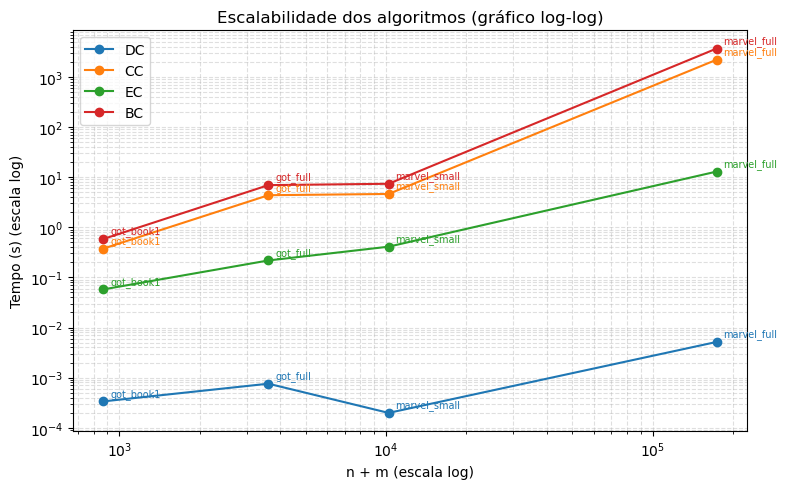

In [16]:
# ── 4.1  Gráfico log-log ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

labels  = ['got_book1', 'got_full', 'marvel_small', 'marvel_full']
colors  = {'DC': 'tab:blue', 'CC': 'tab:orange', 'EC': 'tab:green', 'BC': 'tab:red'}
times   = {'DC': t_dc_list, 'CC': t_cc_list, 'EC': t_ec_list, 'BC': t_bc_list}

fig, ax = plt.subplots(figsize=(8, 5))
for alg, ts in times.items():
    ax.plot(sizes, ts, marker='o', label=alg, color=colors[alg])
    for x, y, label in zip(sizes, ts, labels):
        ax.annotate(f'{label}', (x, y), textcoords='offset points',
                    xytext=(5, 4), fontsize=7, color=colors[alg])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('n + m (escala log)')
ax.set_ylabel('Tempo (s) (escala log)')
ax.set_title('Escalabilidade dos algoritmos (gráfico log-log)')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Time ordering:** $T_{DC} \ll T_{EC} \ll T_{CC} \approx T_{BC}$, consistent with the complexities:

- **DC** ($O(n)$): comes from the `for vid in self._vertex_ids` loop with `degree(vid)` at $O(1)$. In got_book1: 187 operations -> instantaneous. In marvel_full ($n=6421$): 6421 operations, measured at 0.005s.

- **EC** ($O(k \cdot (n+m))$): the `for _ in range(max_iter)` loop runs $k$ times, each iteration scanning $2m$ edges. In got_book1: $16 \times 871 = 13\ 936$ operations; in got_full: $23 \times 3619 = 83\ 237$ operations. $83237/13936 \approx 6.0\times$; measured: $0.218/0.058 \approx 3.8\times$.

- **CC** ($O(n \cdot (n+m))$): the `for vid in self._vertex_ids` loop calls `bfs(vid)` $n$ times. In got_book1: $187 \times 871 = 162\ 877$ operations; in got_full: $796 \times 3619 = 2\ 880\ 724$ operations. $2880724/162877 \approx 17.7\times$; measured: $4.361/0.376 \approx 11.6\times$.

- **BC** ($O(n \cdot (n+m))$): the `for s in all_vertices` loop runs Phase 1 (BFS) + Phase 2 (backtracking), each $O(n+m)$, for each of the $n$ sources. In got_book1: $187 \times 2 \times 871 = 325\ 754$ operations; in got_full: $796 \times 2 \times 3619 = 5\ 769\ 448$ operations. Theoretical ratio: $5769448/325754 \approx 17.7\times$; measured: $6.929/0.584 \approx 11.9\times$.

**Slopes on the log-log plot:** DC has a slope $\approx 1$ (linear). CC and BC have a slope $\approx 2$ (quadratic). EC has a slope $\approx 1$ because $k$ is nearly constant across datasets.

Note: marvel_small has $n+m=10\ 218$ but CC takes 4.619s, similar to got_full ($n+m=3\ 619$, 4.361s). marvel_small has $m=9\ 891$ for only $n=327$, so each vertex's `incident_edges` will be larger, which can make BFS slower.


### 4.2 CC vs BC Comparison

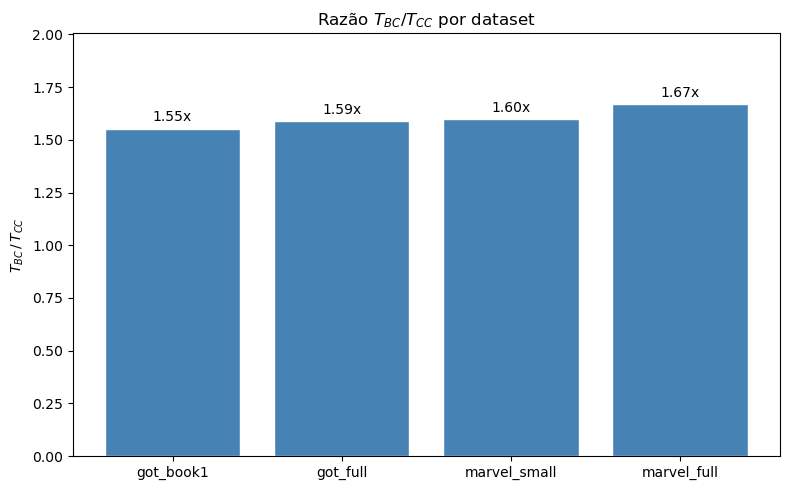

Dataset            TBC (s)    TCC (s)   TBC/TCC
  got_book1            0.584      0.376      1.55x
  got_full             6.929      4.361      1.59x
  marvel_small         7.375      4.619      1.60x
  marvel_full       3678.058   2201.395      1.67x


In [17]:
import matplotlib.pyplot as plt
n_list    = [187, 796, 327, 6421]

datasets_order = ['got_book1.csv', 'got_full.csv', 'marvel_small.csv', 'marvel_full.csv']
labels = ['got_book1', 'got_full', 'marvel_small', 'marvel_full']

ratios_bc_cc = [t_bc / t_cc for t_bc, t_cc in zip(t_bc_list, t_cc_list)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, ratios_bc_cc, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2fx', padding=3)
ax.set_ylabel('$T_{BC}\\,/\\,T_{CC}$')
ax.set_title('Razão $T_{BC}/T_{CC}$ por dataset')
ax.set_ylim(0, max(ratios_bc_cc) * 1.2)
plt.tight_layout()
plt.show()

print(f"{'Dataset':<15s}  {'TBC (s)':>9s}  {'TCC (s)':>9s}  {'TBC/TCC':>8s}")
for label, t_bc, t_cc, r in zip(labels, t_bc_list, t_cc_list, ratios_bc_cc):
    print(f"  {label:<15s}  {t_bc:9.3f}  {t_cc:9.3f}  {r:8.2f}x")

**The ratio ranges between $\approx 1.55\times$ and $1.67\times$** depending on the dataset (got_book1: $1.55\times$, got_full: $1.59\times$, marvel_small: $1.60\times$, marvel_full: $1.67\times$), which implies that BC's and CC's hidden constants are of the same order of magnitude - BC is, on average, about **1.60x slower** than CC, with a narrow range and a slight upward trend as $n+m$ increases.

**Operations that BC performs per source $s$ that CC does not:**

1. **Phase 2 - backtracking** (`while S: w = S.pop(); for v in P[w]: delta[v] += (sigma[v]/sigma[w])*(1.0+delta[w])`): iterates over the stack `S` ($\leq n$ entries) and the predecessor lists `P[w]` (summing to $\leq m$ entries). Additional cost $O(n + m)$ per source - the same as Phase 1, which makes BC do roughly double the work of CC.
2. **Maintaining the stack `S`** (`S.append(v)` at each Phase 1 iteration) and the **predecessor lists** `P[w].append(v)`: structures that `closeness_centrality` does not need to maintain.
3. **Global accumulation** `BC[w] += delta[w]`: $n$ additions per source -> $O(n)$ extra.

The empirical constant varies within a narrow range, between $\approx 1.55$ and $1.67$ (not 2), because Phase 2 includes heavier arithmetic operations (`sigma[v]/sigma[w]`, multiplying by `1.0 + delta[w]`) than the simple distance increment of the BFS in Phase 1 - which makes Phase 2 take proportionally less time than Phase 1 despite having the same number of operations. The slight increase in the ratio with dataset size (from $1.55\times$ in got_book1 to $1.67\times$ in marvel_full) suggests that, in larger graphs, the predecessor lists `P[w]` tend to have more entries on average, bringing Phase 2's cost closer to Phase 1's.


### 4.3 Verification TCC/TEC ≈ n/k

Dataset               n     k       n/k   TCC/TEC
  got_book1           187    16      11.7      6.53
  got_full            796    23      34.6     20.04
  marvel_small        327    14      23.4     11.27
  marvel_full        6421    15     428.1    170.48


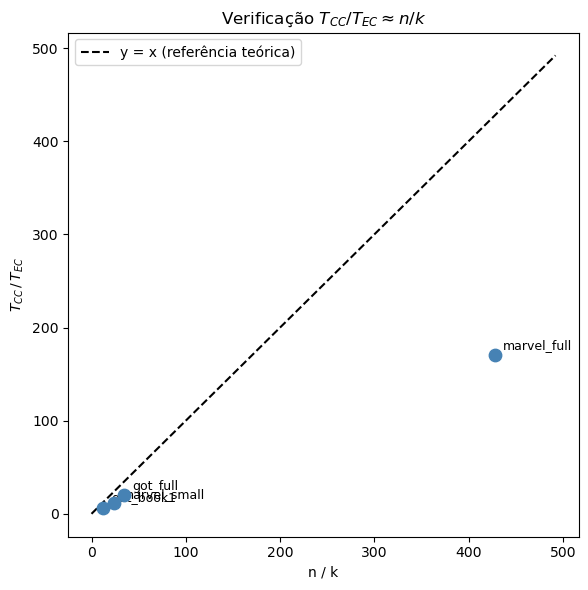

In [18]:
import matplotlib.pyplot as plt

n_over_k   = [n / k for n, k in zip(n_list, k_iterations_list)]
ratio_time = [t_cc / t_ec for t_cc, t_ec in zip(t_cc_list, t_ec_list)]

print(f"{'Dataset':<15s}  {'n':>6s}  {'k':>4s}  {'n/k':>8s}  {'TCC/TEC':>8s}")
for label, n, k, nk, rt in zip(labels, n_list, k_iterations_list, n_over_k, ratio_time):
    print(f"  {label:<15s}  {n:6d}  {k:4d}  {nk:8.1f}  {rt:8.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(n_over_k, ratio_time, zorder=5, s=80, color='steelblue')
for i, label in enumerate(labels):
    ax.annotate(label, (n_over_k[i], ratio_time[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
lim = max(max(n_over_k), max(ratio_time)) * 1.15
ax.plot([0, lim], [0, lim], 'k--', label='y = x (referência teórica)')
ax.set_xlabel('n / k')
ax.set_ylabel('$T_{CC}\\,/\\,T_{EC}$')
ax.set_title('Verificação $T_{CC}/T_{EC} \\approx n/k$')
ax.legend()
plt.tight_layout()
plt.show()


**Justification from the code:**
In `closeness_centrality`, the `for vid in self._vertex_ids` loop calls `bfs(vid)` $n$ times, each BFS costing proportionally to $(n+m)$:
$$T_{CC} = c_1 \cdot n \cdot (n+m)$$
In `eigenvector_centrality`, the `for _ in range(max_iter)` loop runs $k$ times. Each iteration goes through `for node in valid_nodes` and `for edge in incident_edges(node)` - totaling $2m$ examinations - plus $O(n)$ for normalization and convergence:
$$T_{EC} = c_2 \cdot k \cdot (n+m)$$
Therefore: $T_{CC}/T_{EC} = (c_1/c_2) \cdot (n/k)$. If $c_1 \approx c_2$, the ratio is $\approx n/k$.

**Verification against the data:**
- got_book1: $n/k = 187/16 = 11.7$ and $T_{CC}/T_{EC} = 0.376/0.058 \approx 6.53$
- got_full: $n/k = 796/23 = 34.6$ and $T_{CC}/T_{EC} = 4.361/0.218 \approx 20.04$
- marvel_small: $n/k = 327/14 = 23.4$ and $T_{CC}/T_{EC} = 4.619/0.410 \approx 11.27$
- marvel_full: $n/k = 6421/15 = 428.1$ and $T_{CC}/T_{EC} = 2201.395/12.913 \approx 170.48$
Across all datasets, $T_{CC}/T_{EC}$ is below $n/k$ (the points lie below the $y=x$ line), but now consistently across datasets: the ratio $(T_{CC}/T_{EC})/(n/k)$ is $\approx 0.56$ (got_book1), $\approx 0.58$ (got_full), $\approx 0.48$ (marvel_small), and $\approx 0.40$ (marvel_full) - all in the same range, unlike what happened before the `largest_component()` fix (see note below).

**The deviation from $y=x$** ($T_{CC}/T_{EC} < n/k$) indicates that $c_1 < c_2$, i.e., each individual BFS (CC) is faster than each EC iteration. In EC's propagation step, accessing `centrality[neighbour]` inside the `for edge in incident_edges(node)` loop, creating a fresh `new_scores` dictionary on every iteration, and the normalization operations (`max(new_scores.values())`, divisions, comparisons) are more expensive than the BFS's simple distance increment `distances[neighbor_id] = distances[current_id] + 1`. That is why $c_2 > c_1$ and the ratio $T_{CC}/T_{EC}$ falls below $n/k$, though still of the same order of magnitude across all datasets.

**Note on the `largest_component()` fix:** in an earlier version of this notebook, `largest_component()` rebuilt `set(largest_component_vertices)` inside the innermost loop of the subgraph construction, instead of building it once - an efficiency bug that made this function $O(n \cdot m)$ instead of $O(n+m)$. Since `eigenvector_centrality()` calls `largest_component()` once per run, this especially penalized marvel_full (the largest graph): $T_{EC}$ was measured at 221.741s, causing the marvel_full point to fall far below the $y=x$ line ($T_{CC}/T_{EC}\approx 5.05$ instead of the current $\approx 170$). After fixing the `set()` to be built once outside the loop, marvel_full's $T_{EC}$ dropped to 12.913s (a $\approx 17\times$ improvement), and the point's deviation from $y=x$ became the same order of magnitude as the other datasets, confirming that the anomaly was indeed caused by this bug and not by a characteristic of the algorithm.

**The value of $k$ is stable** even as $n$ varies between 187 and 6421. This shows that the `if max_diff < epsilon: break` condition depends on $1 - |\lambda_2|/\lambda_1$ of the adjacency matrix, not on the size of the graph. In these graphs, the spectral gap is very large, which makes convergence fast and makes EC more efficient than CC or BC for large graphs.


## 5. Ethical Questions

### 5.2 References
https://en.wikipedia.org/wiki/Six_degrees_of_separation

Course materials from Design and Analysis of Algorithms 2025/26, Weeks 7 and 8

Mini-Project Support Document
